<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_158/37910743.py:43: SyntaxWarning: invalid escape sequence '\d'
  df['duration'] = df['duration'].str.extract('(\d+)').astype(int)


  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2                 TV Dr

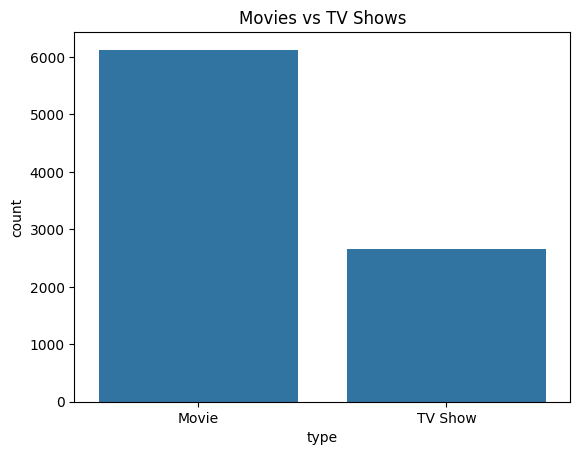

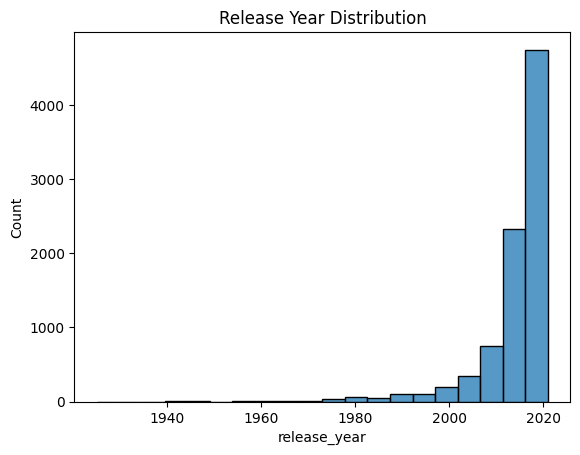

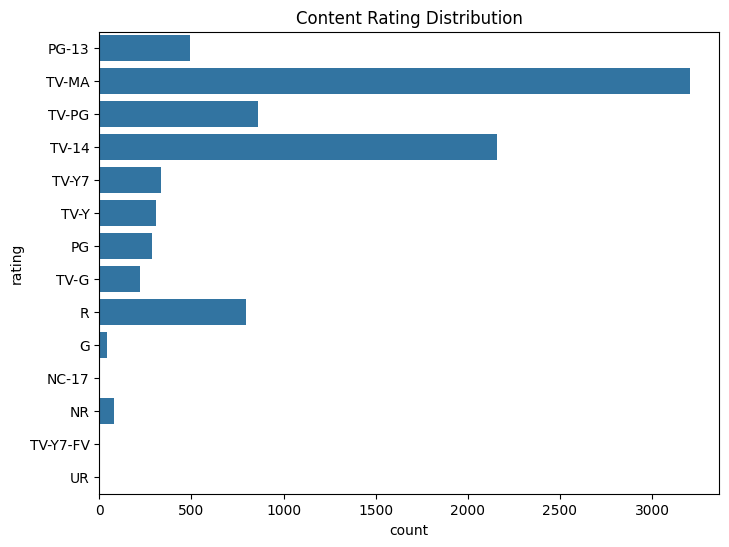

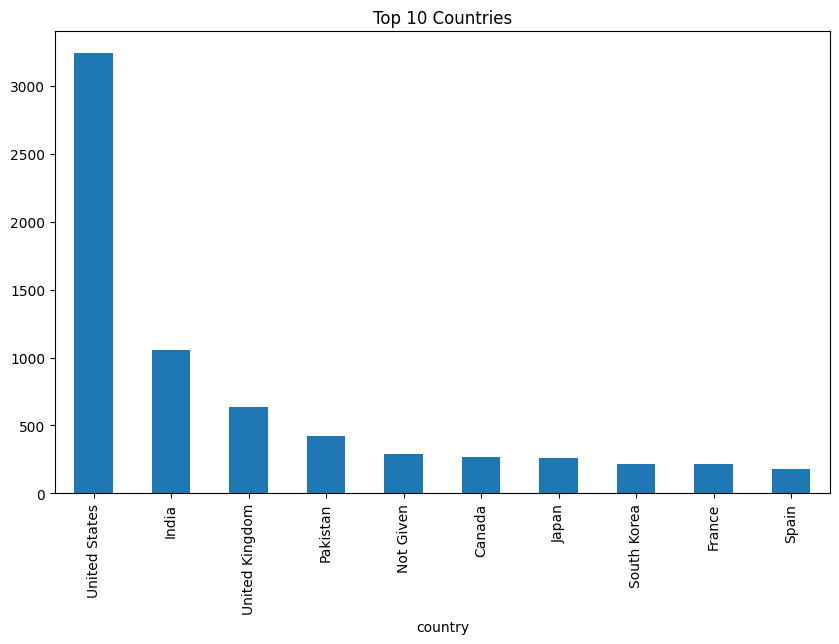

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Accuracy: 0.6882821387940842


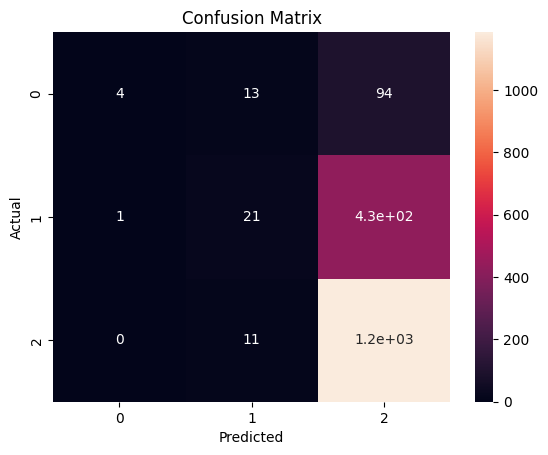

R2 Score: 0.7132887739519631
MAE: 2.8628639605021933
MSE: 22.903166587379527


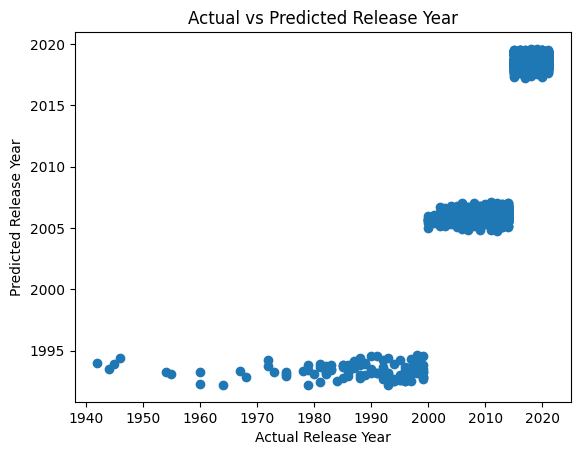

Example Predicted Release Year: [2018.34030774]


In [1]:
#For Netflix Dataset

# ======================================
# 1 Import Libraries
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# ======================================
# 2 Load Dataset
# ======================================

df = pd.read_csv("netflix1.csv")

print(df.head())
print(df.info())


# ======================================
# 3 Basic Data Cleaning
# ======================================

df = df.dropna()

df = df.drop(columns=['show_id','title','date_added'])


# ======================================
# 4 Convert Duration to Number
# ======================================

df['duration'] = df['duration'].str.extract('(\d+)').astype(int)


# ======================================
# 5 Exploratory Data Analysis
# ======================================

# Movies vs TV Shows
plt.figure()
sns.countplot(x=df['type'])
plt.title("Movies vs TV Shows")
plt.show()

# Release Year Distribution
plt.figure()
sns.histplot(df['release_year'], bins=20)
plt.title("Release Year Distribution")
plt.show()

# Rating Distribution
plt.figure(figsize=(8,6))
sns.countplot(y=df['rating'])
plt.title("Content Rating Distribution")
plt.show()

# Top Countries
plt.figure(figsize=(10,6))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()


# ======================================
# 6 Create Popularity Category
# ======================================

def popularity(year):

    if year < 2000:
        return 0
    elif year < 2015:
        return 1
    else:
        return 2


df['Popularity'] = df['release_year'].apply(popularity)


# ======================================
# 7 Encode Categorical Columns
# ======================================

le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])
df['director'] = le.fit_transform(df['director'])
df['country'] = le.fit_transform(df['country'])
df['rating'] = le.fit_transform(df['rating'])
df['listed_in'] = le.fit_transform(df['listed_in'])


# ======================================
# 8 Multinomial Classification
# Logistic Regression
# ======================================

X = df.drop(['Popularity'], axis=1)
y = df['Popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# ======================================
# 9 Classification Evaluation
# ======================================

print("Classification Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ======================================
# 10 Linear Regression
# Predict Release Year
# ======================================

X_reg = df.drop(['release_year'], axis=1)
y_reg = df['release_year']

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg = LinearRegression()

reg.fit(X_train, y_train)

y_pred_reg = reg.predict(X_test)


# ======================================
# 11 Regression Evaluation
# ======================================

print("R2 Score:", r2_score(y_test, y_pred_reg))

print("MAE:", mean_absolute_error(y_test, y_pred_reg))

print("MSE:", mean_squared_error(y_test, y_pred_reg))


# ======================================
# 12 Prediction Plot
# ======================================

plt.figure()

plt.scatter(y_test, y_pred_reg)

plt.xlabel("Actual Release Year")

plt.ylabel("Predicted Release Year")

plt.title("Actual vs Predicted Release Year")

plt.show()


# ======================================
# 13 Example Prediction
# ======================================

sample = X_reg.iloc[0:1]

prediction = reg.predict(sample)

print("Example Predicted Release Year:", prediction)